# FINANCE 361 Lecture 3 Notebook

This notebook is an applied companion to **Lecture 3 (Topic5) — CAPM &  APT**.

Focus:
- Use the **CAPM as a valuation tool** to estimate alpha and beta for each stock in the dataset.
- Identify **seven high-alpha assets** using a `for` loop.
- Reuse the **Lecture 2 tangency-portfolio calculation** to compare an equal-weighted portfolio with a mean-variance optimal portfolio.
- Use the **CAPM as a benchmark** to evaluate both portfolios.
- Repeat the exercise with an **in-sample / out-of-sample split**.


## How to Use This Notebook

1. Run cells from top to bottom (`Shift + Enter`).
2. Read the markdown explanations before each code block.
3. The code intentionally stays close to the previous notebooks, so many variable names and steps should look familiar.
4. If the Ken French download fails, the notebook falls back to the local ZIP file already used in Lecture 2.


In [1]:
from __future__ import annotations

from pathlib import Path

import io
import zipfile
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import requests  # used only if we download Fama-French data
except Exception:
    requests = None

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')


In [2]:
if importlib.util.find_spec('statsmodels') is None:
    raise ModuleNotFoundError(
        "Lecture 3 requires statsmodels. In Jupyter, run: %pip install statsmodels"
    )

import statsmodels.api as sm


## Data Loading and Basic Checks

We start from the stock-return dataset and keep the early diagnostics visible, exactly as in Lecture 2.

In [3]:
data_path = 'dataset.csv'
df_ret = pd.read_csv(data_path, parse_dates=['date'])
df_ret = df_ret.sort_values('date').set_index('date')

print(f'Using data file: {data_path}')
print(f'Rows (months): {df_ret.shape[0]}, Columns (assets): {df_ret.shape[1]}')
df_ret.head()


Using data file: dataset.csv
Rows (months): 324, Columns (assets): 75


,AAPL,ABT,ADBE,AIG,AMD,AMGN,AMZN,AXP,BA,BAC,...,TGT,TMO,TXN,UNH,UNP,USB,VZ,WFC,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
1998-01-01,0.395228,0.081107,-0.066229,0.015086,0.137324,-0.076212,-0.020750,-0.059886,-0.026820,-0.009313,...,0.065741,-0.113636,0.216196,0.031446,-0.035365,-0.036911,0.017170,-0.059678,0.011196,-0.030643
1998-02-01,0.290109,0.060603,0.147727,0.089518,0.164087,0.062500,0.305085,0.076176,0.139108,0.144050,...,0.074717,0.051282,0.061784,0.184146,-0.147917,0.069239,-0.022048,0.125214,0.163265,0.074816
1998-03-01,0.164020,0.006684,0.022631,0.047842,0.236702,0.145882,0.110796,0.019431,-0.036396,0.064781,...,0.140974,-0.015244,-0.066810,0.066942,0.101466,0.004246,0.139276,0.018091,0.097165,0.067853
1998-04-01,-0.004545,-0.029046,0.107884,0.045308,-0.045161,-0.020534,0.072709,0.113002,-0.039568,0.047763,...,-0.007812,-0.013932,0.184758,0.085436,-0.023890,0.072810,-0.084964,-0.040602,-0.003409,0.080406
1998-05-01,-0.027400,0.018531,-0.201929,-0.058907,-0.295045,0.014675,-0.039509,0.006443,-0.046193,-0.006579,...,0.062277,-0.117739,-0.196727,-0.088968,-0.116438,-0.034619,-0.013180,-0.025079,0.090235,-0.035073


In [4]:
df_ret.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 324 entries, 1998-01-01 to 2024-12-01
Data columns (total 75 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    324 non-null    float64
 1   ABT     324 non-null    float64
 2   ADBE    324 non-null    float64
 3   AIG     324 non-null    float64
 4   AMD     324 non-null    float64
 5   AMGN    324 non-null    float64
 6   AMZN    324 non-null    float64
 7   AXP     324 non-null    float64
 8   BA      324 non-null    float64
 9   BAC     324 non-null    float64
 10  BK      324 non-null    float64
 11  BMY     324 non-null    float64
 12  BRK-B   324 non-null    float64
 13  C       324 non-null    float64
 14  CAT     324 non-null    float64
 15  CL      324 non-null    float64
 16  CMCSA   324 non-null    float64
 17  COF     324 non-null    float64
 18  COP     324 non-null    float64
 19  COST    324 non-null    float64
 20  CSCO    324 non-null    float64
 21  CVS     324 non-null    float64

In [5]:
# Full descriptive statistics for all available assets.
df_ret.describe().T

,count,mean,std,min,25%,50%,75%,max
AAPL,324.000000,0.031381,0.115287,-0.577437,-0.033722,0.033053,0.099804,0.453782
ABT,324.000000,0.010066,0.057651,-0.207369,-0.026212,0.012491,0.047652,0.167026
ADBE,324.000000,0.020393,0.116742,-0.334615,-0.045436,0.029320,0.081383,0.852440
AIG,324.000000,0.009463,0.194980,-0.845044,-0.044087,0.008069,0.050339,2.449771
AMD,324.000000,0.024974,0.187286,-0.410489,-0.088293,0.007537,0.148551,0.780996
...,...,...,...,...,...,...,...,...
USB,324.000000,0.008860,0.081197,-0.396053,-0.031278,0.009660,0.048593,0.287719
VZ,324.000000,0.005763,0.064446,-0.204781,-0.032732,0.001749,0.045248,0.376093
WFC,324.000000,0.009878,0.085143,-0.359789,-0.028550,0.010639,0.044047,0.405196
WMT,324.000000,0.011311,0.060263,-0.207365,-0.023433,0.011023,0.044410,0.265881


## Risk-Free Rate ($r_f$) and Market Excess Return via Fama--French

As in Lecture 2, we merge the stock-return dataset with the Ken French factor file.
We need two columns for the CAPM:
- `RF`: the monthly risk-free rate,
- `Mkt-RF`: the market excess return.

The Ken French file reports values in percent, so we divide by 100 to convert them to decimal returns.

In [6]:
USE_FAMA_FRENCH_RF = True

# Ken French data library (Dartmouth) — loading the data directly from the URL.
FF_ZIP_URL = 'https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_5_Factors_2x3_CSV.zip'
LOCAL_FF_ZIP = Path('../../Lecture_2/Code/Source/F-F_Research_Data_5_Factors_2x3_CSV.zip')


In [7]:
def read_ff_zip(zip_bytes: bytes) -> pd.DataFrame:
    z = zipfile.ZipFile(io.BytesIO(zip_bytes))
    csv_filename = z.namelist()[0]
    with z.open(csv_filename) as file:
        df_factors = pd.read_csv(file, skiprows=3, index_col=0)

    # Keep monthly data only (cut before the annual section begins).
    df_factors = df_factors.loc[:'202412']
    df_factors.index = pd.to_datetime(df_factors.index, format='%Y%m')
    df_factors = df_factors.apply(pd.to_numeric) / 100.0  # convert % to decimal
    df_factors = df_factors.rename_axis('date').reset_index()
    return df_factors


if USE_FAMA_FRENCH_RF:
    try:
        if requests is None:
            raise ModuleNotFoundError('requests is not available')

        # Download the ZIP file
        response = requests.get(FF_ZIP_URL, timeout=30)
        response.raise_for_status()
        df_factors = read_ff_zip(response.content)

        # Merge with returns (inner join: keeps only common dates).
        df = df_ret.reset_index().merge(df_factors, how='inner', on='date').set_index('date').sort_index()
        print('Using Ken French website download.')

    except Exception as e:
        if LOCAL_FF_ZIP.exists():
            print(f'Download failed ({type(e).__name__}). Using local fallback ZIP instead.')
            df_factors = read_ff_zip(LOCAL_FF_ZIP.read_bytes())
            df = df_ret.reset_index().merge(df_factors, how='inner', on='date').set_index('date').sort_index()
        else:
            print(f'Download failed ({type(e).__name__}). Proceeding with r_f = 0.')
            USE_FAMA_FRENCH_RF = False

else:
    # Offline/error fallback: proceed with r_f = 0 and no factor columns.
    df = df_ret.copy()

print(f'Merged dataset rows: {df.shape[0]} (324 months from 1998-01 to 2024-12)')
df.head()


Using Ken French website download.
Merged dataset rows: 324 (324 months from 1998-01 to 2024-12)


,AAPL,ABT,ADBE,AIG,AMD,AMGN,AMZN,AXP,BA,BAC,...,VZ,WFC,WMT,XOM,Mkt-RF,SMB,HML,RMW,CMA,RF
date,,,,,,,,,,,,,,,,,,,,,
1998-01-01,0.395228,0.081107,-0.066229,0.015086,0.137324,-0.076212,-0.020750,-0.059886,-0.026820,-0.009313,...,0.017170,-0.059678,0.011196,-0.030643,0.001400,-0.012800,-0.016800,0.009100,-0.006200,0.004300
1998-02-01,0.290109,0.060603,0.147727,0.089518,0.164087,0.062500,0.305085,0.076176,0.139108,0.144050,...,-0.022048,0.125214,0.163265,0.074816,0.070400,0.000500,-0.009300,-0.003700,-0.025800,0.003900
1998-03-01,0.164020,0.006684,0.022631,0.047842,0.236702,0.145882,0.110796,0.019431,-0.036396,0.064781,...,0.139276,0.018091,0.097165,0.067853,0.047600,-0.007300,0.013800,-0.005500,-0.002300,0.003900
1998-04-01,-0.004545,-0.029046,0.107884,0.045308,-0.045161,-0.020534,0.072709,0.113002,-0.039568,0.047763,...,-0.084964,-0.040602,-0.003409,0.080406,0.007400,0.000100,0.010300,-0.016800,-0.003600,0.004300
1998-05-01,-0.027400,0.018531,-0.201929,-0.058907,-0.295045,0.014675,-0.039509,0.006443,-0.046193,-0.006579,...,-0.013180,-0.025079,0.090235,-0.035073,-0.030500,-0.030000,0.034100,0.010300,0.024700,0.004000


## CAPM as a Valuation Tool

For each stock we run the CAPM time-series regression

$$r_{i,t} - r_{f,t} = \alpha_i + \beta_i (r_{m,t} - r_{f,t}) + \varepsilon_{i,t}.$$

This is the same `statsmodels` workflow used in Lecture 1:
- create `X` with `sm.add_constant(...)`,
- define `y`,
- fit the OLS model,
- read alpha, beta, and regression diagnostics from the output.

A positive alpha means the stock delivered more excess return than the CAPM benchmark would predict over the sample.

In [8]:
def run_capm_table(returns: pd.DataFrame, market_excess: pd.Series, rf: pd.Series) -> pd.DataFrame:
    rows = []
    for ticker in returns.columns:
        X = sm.add_constant(market_excess)
        y = returns[ticker] - rf
        model = sm.OLS(y, X).fit()

        rows.append({
            'Ticker': ticker,
            'Mean excess return (monthly)': y.mean(),
            'CAPM required excess return (monthly)': model.params['Mkt-RF'] * market_excess.mean(),
            'Alpha (monthly)': model.params['const'],
            'Alpha (annualised)': (1 + model.params['const']) ** 12 - 1,
            'Beta': model.params['Mkt-RF'],
            'Alpha t-stat': model.tvalues['const'],
            'R-squared': model.rsquared,
        })

    return pd.DataFrame(rows).sort_values(['Alpha (monthly)', 'Alpha t-stat'], ascending=False).set_index('Ticker')

In [9]:
available_tickers = df_ret.columns.tolist()
market_excess = df['Mkt-RF'] if USE_FAMA_FRENCH_RF and 'Mkt-RF' in df.columns else pd.Series(0.0, index=df.index, name='Mkt-RF')
rf = df['RF'] if USE_FAMA_FRENCH_RF and 'RF' in df.columns else pd.Series(0.0, index=df.index, name='RF')

alpha_table = run_capm_table(df_ret[available_tickers], market_excess, rf)
my_stock_selection = alpha_table.head(7).index.tolist()

print('Top 7 high-alpha assets from the full sample:')
print(my_stock_selection)
alpha_table.head(10)


Top 7 high-alpha assets from the full sample:
['AAPL', 'AMZN', 'GILD', 'MO', 'UNH', 'QCOM', 'INTU']


,Mean excess return (monthly),CAPM required excess return (monthly),Alpha (monthly),Alpha (annualised),Beta,Alpha t-stat,R-squared
Ticker,,,,,,,
AAPL,0.029730,0.008856,0.020873,0.281335,1.320161,3.804102,0.282814
AMZN,0.030126,0.010787,0.019339,0.258418,1.607875,2.519141,0.230078
GILD,0.017851,0.004881,0.012969,0.167227,0.727643,2.344014,0.105403
MO,0.015200,0.003801,0.011399,0.145698,0.566587,1.501315,0.036549
UNH,0.015561,0.004536,0.011025,0.140625,0.676080,2.928969,0.180172
QCOM,0.019874,0.009238,0.010636,0.135364,1.377042,1.599419,0.226090
INTU,0.017978,0.007964,0.010014,0.127018,1.187052,1.957943,0.268435
ADBE,0.018743,0.009749,0.008994,0.113429,1.453186,1.679983,0.334194
DHR,0.014303,0.005737,0.008566,0.107770,0.855165,2.383920,0.278444


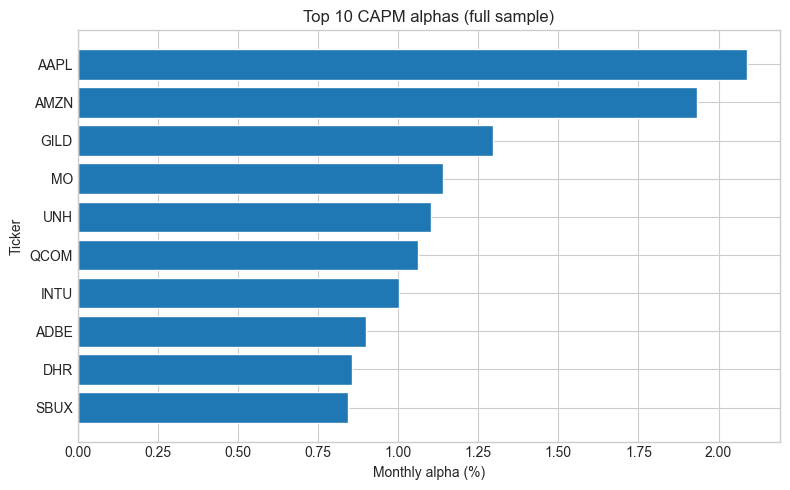

In [10]:
plot_table = alpha_table.head(10).copy().iloc[::-1]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(plot_table.index, 100 * plot_table['Alpha (monthly)'], color='tab:blue')
ax.set_title('Top 10 CAPM alphas (full sample)')
ax.set_xlabel('Monthly alpha (%)')
ax.set_ylabel('Ticker')
plt.tight_layout()
plt.show()


## Stock Selection

Just as in Lecture 2, we explicitly create a stock-selection list and then subset the data. Here the list is **chosen by CAPM alpha**, rather than entered manually.

In [11]:
missing = sorted(set(my_stock_selection) - set(df.columns))
if missing:
    raise ValueError(f'Tickers not found in data: {missing}')

stocks = df[my_stock_selection].copy()
stocks.describe().T


,count,mean,std,min,25%,50%,75%,max
AAPL,324.000000,0.031381,0.115287,-0.577437,-0.033722,0.033053,0.099804,0.453782
AMZN,324.000000,0.031776,0.155658,-0.411552,-0.046218,0.023922,0.095900,1.263827
GILD,324.000000,0.019501,0.104133,-0.267056,-0.040504,0.009791,0.069100,0.634178
MO,324.000000,0.016851,0.137587,-0.696472,-0.030883,0.018978,0.055672,1.951944
UNH,324.000000,0.017211,0.073825,-0.360619,-0.024751,0.021778,0.061205,0.266064
QCOM,324.000000,0.021524,0.134571,-0.387896,-0.042707,0.014420,0.068788,0.944454
INTU,324.000000,0.019629,0.106401,-0.339080,-0.033382,0.017511,0.069605,0.761029


## Correlations (Diversification Intuition)

Correlation is not the optimisation input (that is $\Sigma$), but it is still a quick way to see whether diversification is likely to help.

In [12]:
corr = stocks.corr()
corr

,AAPL,AMZN,GILD,MO,UNH,QCOM,INTU
AAPL,1.000000,0.350172,0.171281,0.149281,0.158988,0.309118,0.287128
AMZN,0.350172,1.000000,0.223068,0.043641,0.117647,0.265101,0.444104
GILD,0.171281,0.223068,1.000000,-0.000469,0.229012,0.147185,0.219437
MO,0.149281,0.043641,-0.000469,1.000000,0.153070,-0.007477,0.075110
UNH,0.158988,0.117647,0.229012,0.153070,1.000000,0.140281,0.226674
QCOM,0.309118,0.265101,0.147185,-0.007477,0.140281,1.000000,0.263307
INTU,0.287128,0.444104,0.219437,0.075110,0.226674,0.263307,1.000000


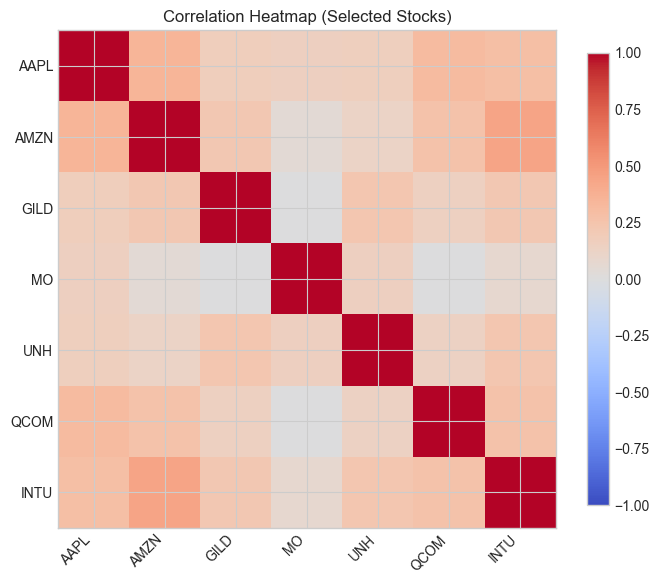

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
image = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(my_stock_selection)))
ax.set_yticks(range(len(my_stock_selection)))
ax.set_xticklabels(my_stock_selection, rotation=45, ha='right')
ax.set_yticklabels(my_stock_selection)
ax.set_title('Correlation Heatmap (Selected Stocks)')
fig.colorbar(image, ax=ax, shrink=0.85)
plt.tight_layout()
plt.show()


## Portfolio Inputs: $\mu$ and $\Sigma$

For portfolio weights $w$ and return vector $r$:
- Expected excess return: $\mathbb{E}[r_p^e] = w^\top \mu^e$
- Variance: $\mathrm{Var}(r_p) = w^\top \Sigma w$

We estimate $\Sigma$ from historical data exactly as in Lecture 2.

In [14]:
# Population-style covariance estimate from the lecture notes: Sigma_hat = (1/T) R^T R
R = stocks.subtract(stocks.mean())
T = len(stocks)
Sigma_pop = (R.T @ R) / T

# Unbiased sample estimate divides by (T-1) instead.
Sigma_samp = (R.T @ R) / (T - 1)

Sigma = Sigma_pop
Sigma.head()

,AAPL,AMZN,GILD,MO,UNH,QCOM,INTU
AAPL,0.013250,0.006265,0.002050,0.002361,0.001349,0.004781,0.003511
AMZN,0.006265,0.024155,0.003605,0.000932,0.001348,0.005536,0.007333
GILD,0.002050,0.003605,0.010810,-0.000007,0.001755,0.002056,0.002424
MO,0.002361,0.000932,-0.000007,0.018872,0.001550,-0.000138,0.001096
UNH,0.001349,0.001348,0.001755,0.001550,0.005433,0.001389,0.001775


## Excess Returns

The tangency portfolio uses the vector of expected excess returns:

$$\mu^e = \mathbb{E}[r_t - r_{f,t}].$$

In [15]:
stocks_excess = stocks.subtract(rf, axis=0)
mu_e = stocks_excess.mean()
mu_e

AAPL   0.029730
AMZN   0.030126
GILD   0.017851
MO     0.015200
UNH    0.015561
QCOM   0.019874
INTU   0.017978
dtype: float64

## Markowitz Tangency (Maximum Sharpe) Portfolio

With weights summing to one ($\mathbf{1}^\top w = 1$), the tangency portfolio weights are:

$$w^\star = \frac{\Sigma^{-1}\mu^e}{\mathbf{1}^\top\Sigma^{-1}\mu^e}.$$

In [16]:
def tangency_weights(Sigma: np.ndarray, mu_excess: np.ndarray) -> np.ndarray:
    mu_excess = np.asarray(mu_excess, dtype=float).reshape(-1)
    ones = np.ones_like(mu_excess)

    z = np.linalg.pinv(Sigma) @ mu_excess

    denom = ones @ z
    if np.isclose(denom, 0.0):
        raise ValueError('Normalisation failed: 1^T Σ^{+} μ^e is ~0.')

    return z / denom


In [17]:
w_mkv = tangency_weights(Sigma.values if hasattr(Sigma, 'values') else Sigma, mu_e.values)
w_mkv = pd.Series(w_mkv, index=my_stock_selection, name='Mean-variance optimal')

w_eq = pd.Series(np.repeat(1 / len(my_stock_selection), len(my_stock_selection)), index=my_stock_selection, name='Equal-weighted')

weights_compare = pd.concat([w_eq, w_mkv], axis=1)
weights_compare

,Equal-weighted,Mean-variance optimal
AAPL,0.142857,0.262592
AMZN,0.142857,0.089793
GILD,0.142857,0.145280
MO,0.142857,0.078671
UNH,0.142857,0.333461
QCOM,0.142857,0.051676
INTU,0.142857,0.038527


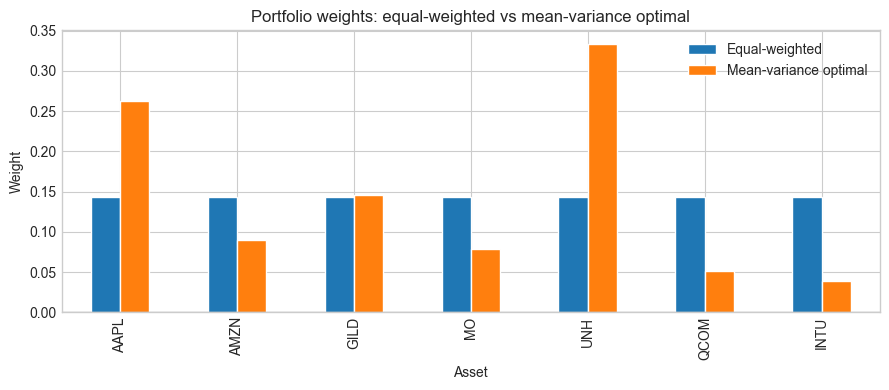

In [18]:
ax = weights_compare.plot(kind='bar', figsize=(9, 4), title='Portfolio weights: equal-weighted vs mean-variance optimal')
ax.set_xlabel('Asset')
ax.set_ylabel('Weight')
ax.axhline(0.0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## CAPM Evaluation of the Portfolios

After the portfolios are formed, we can still use the CAPM as a benchmark. We run the CAPM regression again, now on the **portfolio excess return**.

In [19]:
def portfolio_capm_summary(weights: pd.Series, returns: pd.DataFrame, rf: pd.Series, market_excess: pd.Series) -> pd.Series:
    portfolio_total = returns @ weights
    portfolio_excess = portfolio_total - rf

    X = sm.add_constant(market_excess)
    model = sm.OLS(portfolio_excess, X).fit()

    mean_excess = portfolio_excess.mean()
    sig = portfolio_excess.std(ddof=1)

    return pd.Series({
        'E[excess] (monthly)': mean_excess,
        'Vol (monthly)': sig,
        'Sharpe (monthly)': mean_excess / sig,
        'CAPM beta': model.params['Mkt-RF'],
        'CAPM required excess (monthly)': model.params['Mkt-RF'] * market_excess.mean(),
        'CAPM alpha (monthly)': model.params['const'],
        'CAPM alpha t-stat': model.tvalues['const'],
        'R-squared': model.rsquared,
    }, name=weights.name)


def market_capm_summary(market_excess: pd.Series) -> pd.Series:
    """CAPM benchmark row for the market portfolio.
    By construction: beta = 1, alpha = 0, R-squared = 1."""
    mean_excess = market_excess.mean()
    sig = market_excess.std(ddof=1)
    return pd.Series({
        'E[excess] (monthly)': mean_excess,
        'Vol (monthly)': sig,
        'Sharpe (monthly)': mean_excess / sig,
        'CAPM beta': 1.0,
        'CAPM required excess (monthly)': mean_excess,
        'CAPM alpha (monthly)': 0.0,
        'CAPM alpha t-stat': 0.0,
        'R-squared': 1.0,
    }, name='Market')


perf_full = pd.concat([
    portfolio_capm_summary(w_eq, stocks, rf, market_excess),
    portfolio_capm_summary(w_mkv, stocks, rf, market_excess),
    market_capm_summary(market_excess),
], axis=1).T
perf_full

,E[excess] (monthly),Vol (monthly),Sharpe (monthly),CAPM beta,CAPM required excess (monthly),CAPM alpha (monthly),CAPM alpha t-stat,R-squared
Equal-weighted,0.020903,0.065703,0.318137,1.066063,0.007152,0.013751,5.659664,0.567391
Mean-variance optimal,0.021210,0.061900,0.342642,0.983665,0.006599,0.014611,6.218880,0.544259
Market,0.006709,0.046424,0.144507,1.000000,0.006709,0.000000,0.000000,1.000000


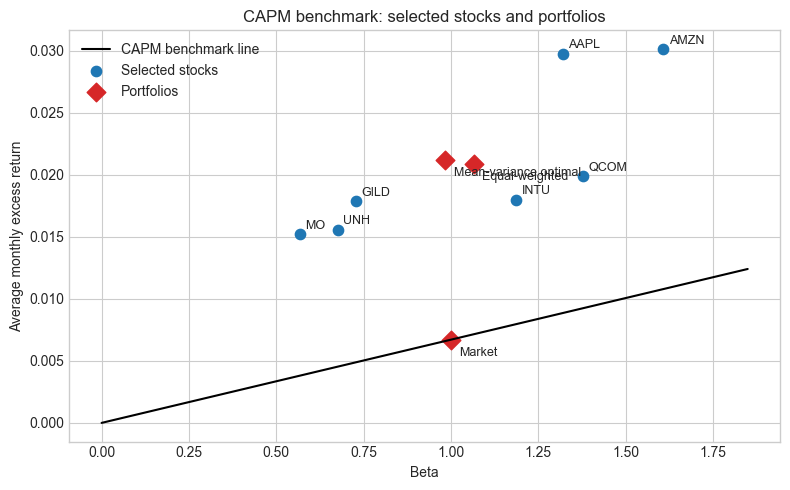

In [20]:
market_premium = market_excess.mean()
asset_points = alpha_table.loc[my_stock_selection, ['Beta', 'Mean excess return (monthly)']].copy()

fig, ax = plt.subplots(figsize=(8, 5))

beta_grid = np.linspace(0, max(asset_points['Beta'].max(), perf_full['CAPM beta'].max()) * 1.15, 100)
ax.plot(beta_grid, market_premium * beta_grid, color='black', linewidth=1.5, label='CAPM benchmark line')
ax.scatter(asset_points['Beta'], asset_points['Mean excess return (monthly)'], color='tab:blue', s=55, label='Selected stocks')
ax.scatter(perf_full['CAPM beta'], perf_full['E[excess] (monthly)'], color='tab:red', marker='D', s=90, label='Portfolios')

for ticker, row in asset_points.iterrows():
    ax.annotate(ticker, (row['Beta'], row['Mean excess return (monthly)']), xytext=(4, 4), textcoords='offset points', fontsize=9)
for portfolio_name, row in perf_full.iterrows():
    ax.annotate(portfolio_name, (row['CAPM beta'], row['E[excess] (monthly)']), xytext=(6, -12), textcoords='offset points', fontsize=9)

ax.set_title('CAPM benchmark: selected stocks and portfolios')
ax.set_xlabel('Beta')
ax.set_ylabel('Average monthly excess return')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()


## In-Sample / Out-of-Sample Analysis

Up to this point, we have used the **full sample** for both selection and evaluation. That is useful for teaching the mechanics, but it can be overly optimistic.

We now split the sample at **January 2015**, giving:
- **In-sample:** 1998–2014 (204 months, ~63% of the data)
- **Out-of-sample:** 2015–2024 (120 months, ~37% of the data)

The split date is controlled by `SPLIT_DATE` below and can be moved to explore different windows. The seven stocks and the portfolio weights are chosen using only the in-sample data. Then we evaluate those same choices out-of-sample.

In [21]:
# Change SPLIT_DATE to move the in-sample/out-of-sample boundary.
# Must fall within the dataset range: 1998-01-01 to 2024-12-01.
SPLIT_DATE = pd.Timestamp('2015-01-01')

train = df.loc[df.index < SPLIT_DATE].copy()
test  = df.loc[df.index >= SPLIT_DATE].copy()

print(f'Split date: {SPLIT_DATE.date()}')
print(f'In-sample observations:     {len(train)}')
print(f'Out-of-sample observations: {len(test)}')

Split date: 2015-01-01
In-sample observations:     204
Out-of-sample observations: 120


In [22]:
train_alpha_table = run_capm_table(train[df_ret.columns], train['Mkt-RF'], train['RF'])
train_selection = train_alpha_table.head(7).index.tolist()

print('Top 7 in-sample alpha assets:')
print(train_selection)
train_alpha_table.head(10)


Top 7 in-sample alpha assets:
['AAPL', 'AMZN', 'GILD', 'MO', 'QCOM', 'SBUX', 'UNH']


,Mean excess return (monthly),CAPM required excess return (monthly),Alpha (monthly),Alpha (annualised),Beta,Alpha t-stat,R-squared
Ticker,,,,,,,
AAPL,0.034731,0.006953,0.027779,0.389302,1.426161,3.463637,0.256045
AMZN,0.033297,0.009012,0.024285,0.333670,1.848654,2.117715,0.220494
GILD,0.026302,0.004402,0.021900,0.296884,0.903056,2.780736,0.125190
MO,0.020197,0.002798,0.017399,0.229970,0.574004,1.511146,0.026340
QCOM,0.024085,0.006937,0.017148,0.226339,1.422934,1.856798,0.205329
SBUX,0.017995,0.005084,0.012911,0.166418,1.042832,2.013423,0.223522
UNH,0.015816,0.003506,0.012310,0.158143,0.719158,2.358996,0.171309
INTU,0.018005,0.005929,0.012076,0.154934,1.216173,1.575788,0.215145
ADBE,0.019532,0.007857,0.011675,0.149458,1.611707,1.525961,0.325683


In [23]:
stocks_train = train[train_selection].copy()
stocks_excess_train = stocks_train.subtract(train['RF'], axis=0)
mu_e_train = stocks_excess_train.mean()

R_train = stocks_train.subtract(stocks_train.mean())
T_train = len(stocks_train)
Sigma_train = (R_train.T @ R_train) / T_train

w_mkv_train = tangency_weights(Sigma_train.values if hasattr(Sigma_train, 'values') else Sigma_train, mu_e_train.values)
w_mkv_train = pd.Series(w_mkv_train, index=train_selection, name='Mean-variance optimal')

w_eq_train = pd.Series(np.repeat(1 / len(train_selection), len(train_selection)), index=train_selection, name='Equal-weighted')

pd.concat([w_eq_train, w_mkv_train], axis=1)

,Equal-weighted,Mean-variance optimal
AAPL,0.142857,0.223947
AMZN,0.142857,0.044345
GILD,0.142857,0.221435
MO,0.142857,0.104385
QCOM,0.142857,0.080973
SBUX,0.142857,0.122582
UNH,0.142857,0.202334


In [24]:
perf_train = pd.concat([
    portfolio_capm_summary(w_eq_train, train[train_selection], train['RF'], train['Mkt-RF']),
    portfolio_capm_summary(w_mkv_train, train[train_selection], train['RF'], train['Mkt-RF']),
    market_capm_summary(train['Mkt-RF']),
], axis=1).T
perf_train.insert(0, 'Sample', 'In-sample')

perf_test = pd.concat([
    portfolio_capm_summary(w_eq_train, test[train_selection], test['RF'], test['Mkt-RF']),
    portfolio_capm_summary(w_mkv_train, test[train_selection], test['RF'], test['Mkt-RF']),
    market_capm_summary(test['Mkt-RF']),
], axis=1).T
perf_test.insert(0, 'Sample', 'Out-of-sample')

perf_split = pd.concat([perf_train, perf_test])
perf_split

,Sample,E[excess] (monthly),Vol (monthly),Sharpe (monthly),CAPM beta,CAPM required excess (monthly),CAPM alpha (monthly),CAPM alpha t-stat,R-squared
Equal-weighted,In-sample,0.024632,0.070041,0.351680,1.133828,0.005527,0.019104,5.913176,0.572739
Mean-variance optimal,In-sample,0.024543,0.066084,0.371391,1.049810,0.005118,0.019425,6.220084,0.551551
Market,In-sample,0.004875,0.046750,0.104278,1.000000,0.004875,0.000000,0.000000,1.000000
Equal-weighted,Out-of-sample,0.013318,0.047576,0.279931,0.873317,0.008581,0.004737,1.970497,0.709627
Mean-variance optimal,Out-of-sample,0.012544,0.045354,0.276582,0.800711,0.007868,0.004676,1.876006,0.656438
Market,Out-of-sample,0.009826,0.045891,0.214110,1.000000,0.009826,0.000000,0.000000,1.000000


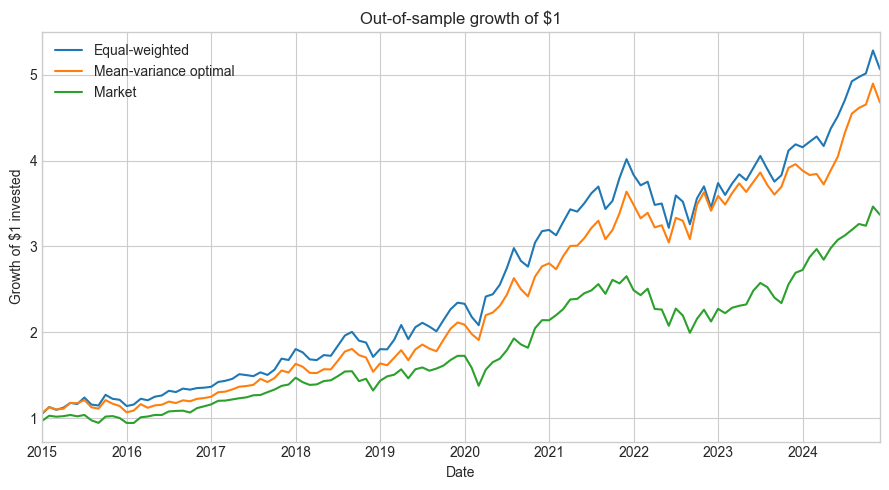

In [25]:
portfolio_eq_test = test[train_selection] @ w_eq_train
portfolio_mkv_test = test[train_selection] @ w_mkv_train
market_test = test['Mkt-RF'] + test['RF']

wealth_paths = pd.DataFrame({
    'Equal-weighted': (1 + portfolio_eq_test).cumprod(),
    'Mean-variance optimal': (1 + portfolio_mkv_test).cumprod(),
    'Market': (1 + market_test).cumprod(),
}, index=test.index)

ax = wealth_paths.plot(figsize=(9, 5))
ax.set_title('Out-of-sample growth of $1')
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 invested')
plt.tight_layout()
plt.show()
